# Análise de cancelamento de clientes

## Objetivo

Identificar características **associadas** ao cancelamento de clientes e transformar os resultados em recomendações que possam ser testadas pela empresa.

Perguntas principais:

1. Qual é a taxa geral de cancelamento?
2. Como a taxa varia conforme o contrato?
3. Existe associação entre contatos com o call center e cancelamento?
4. Como o atraso no pagamento se relaciona com o churn?
5. A ausência de interação recente aparece como sinal de risco?

> **Escopo e origem:** esta é uma base educacional indicada no material original do projeto *Python Insights*. Os registros não são apresentados como dados reais de uma empresa. A análise é descritiva: associação não significa causalidade.

In [1]:
from pathlib import Path

import pandas as pd
import plotly.express as px
from IPython.display import Image, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PALETTE = {"Não cancelou": "#2E6F95", "Cancelou": "#E07A5F"}

current = Path.cwd()
PROJECT_ROOT = current.parent if current.name == "notebooks" else current
DATA_PATH = PROJECT_ROOT / "data" / "cancelamentos.csv"
IMAGES_DIR = PROJECT_ROOT / "imagens"
IMAGES_DIR.mkdir(exist_ok=True)

def percent(value):
    return f"{value:.2%}".replace(".", ",")

def finish_chart(fig, filename, height=560):
    fig.update_layout(
        template="plotly_white",
        font=dict(family="Arial", size=15, color="#243447"),
        title=dict(x=0.02, xanchor="left"),
        margin=dict(l=70, r=40, t=90, b=70),
        legend_title_text="",
        height=height,
    )
    path = IMAGES_DIR / filename
    fig.write_image(path, width=1100, height=height, scale=1.4)
    display(Image(filename=str(path)))
    return path

DATA_PATH

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/data/cancelamentos.csv')

## 1. Leitura e auditoria da base

Antes de produzir gráficos, a qualidade do arquivo precisa ser medida. Duplicidades e ausências alteram contagens e podem distorcer taxas.

In [2]:
raw = pd.read_csv(DATA_PATH)

quality = pd.DataFrame({
    "Métrica": [
        "Linhas originais",
        "Colunas",
        "Linhas exatamente duplicadas",
        "Linhas com algum valor ausente",
        "IDs de cliente repetidos",
    ],
    "Resultado": [
        len(raw),
        raw.shape[1],
        int(raw.duplicated().sum()),
        int(raw.isna().any(axis=1).sum()),
        int(raw["CustomerID"].duplicated().sum()),
    ],
})

display(quality)
display(raw.head())

,Métrica,Resultado
0,Linhas originais,50000
1,Colunas,12
2,Linhas exatamente duplicadas,1469
3,Linhas com algum valor ausente,4
4,IDs de cliente repetidos,1469


,CustomerID,idade,sexo,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,assinatura,duracao_contrato,total_gasto,meses_ultima_interacao,cancelou
0,"349,936.00",23.00,Male,13.00,22.00,2.00,1.00,Standard,Annual,909.58,23.00,0.00
1,"100,634.00",49.00,Male,55.00,16.00,3.00,6.00,Premium,Monthly,207.00,29.00,1.00
2,"301,263.00",30.00,Male,7.00,1.00,0.00,8.00,Basic,Annual,768.78,7.00,0.00
3,"119,358.00",26.00,Male,40.00,5.00,3.00,8.00,Premium,Annual,398.00,12.00,1.00
4,"130,955.00",27.00,Female,17.00,30.00,5.00,6.00,Basic,Annual,507.00,15.00,1.00


### Decisão de limpeza

- As 1.469 linhas exatamente duplicadas são removidas para que o mesmo cliente não conte duas vezes.
- Quatro linhas ainda possuem pelo menos um valor ausente. Elas representam menos de 0,01% do arquivo e são removidas.
- `CustomerID` é mantido apenas durante a validação de duplicidades e depois excluído, pois funciona como identificador, não como variável explicativa.
- O resultado é uma amostra analítica com **48.527 clientes**.

In [3]:
data = (
    raw
    .drop_duplicates()
    .dropna()
    .drop(columns="CustomerID")
    .copy()
)

integer_columns = [
    "idade",
    "tempo_como_cliente",
    "frequencia_uso",
    "ligacoes_callcenter",
    "dias_atraso",
    "meses_ultima_interacao",
    "cancelou",
]
data[integer_columns] = data[integer_columns].astype(int)

assert len(data) == 48_527
assert set(data["cancelou"].unique()) == {0, 1}
assert not data.isna().any().any()

summary = pd.DataFrame({
    "Métrica": ["Registros analisados", "Clientes que cancelaram", "Clientes que permaneceram", "Taxa de cancelamento"],
    "Resultado": [
        f"{len(data):,}".replace(",", "."),
        f"{int(data['cancelou'].sum()):,}".replace(",", "."),
        f"{int((data['cancelou'] == 0).sum()):,}".replace(",", "."),
        percent(data["cancelou"].mean()),
    ],
})
display(summary)

,Métrica,Resultado
0,Registros analisados,48.527
1,Clientes que cancelaram,27.539
2,Clientes que permaneceram,20.988
3,Taxa de cancelamento,"56,75%"


## 2. Taxa geral de cancelamento

A taxa observada é alta: **56,75%** dos 48.527 clientes da amostra limpa aparecem como cancelados. Esse número descreve a base; não deve ser generalizado para uma empresa real sem validar a origem e o período dos dados.

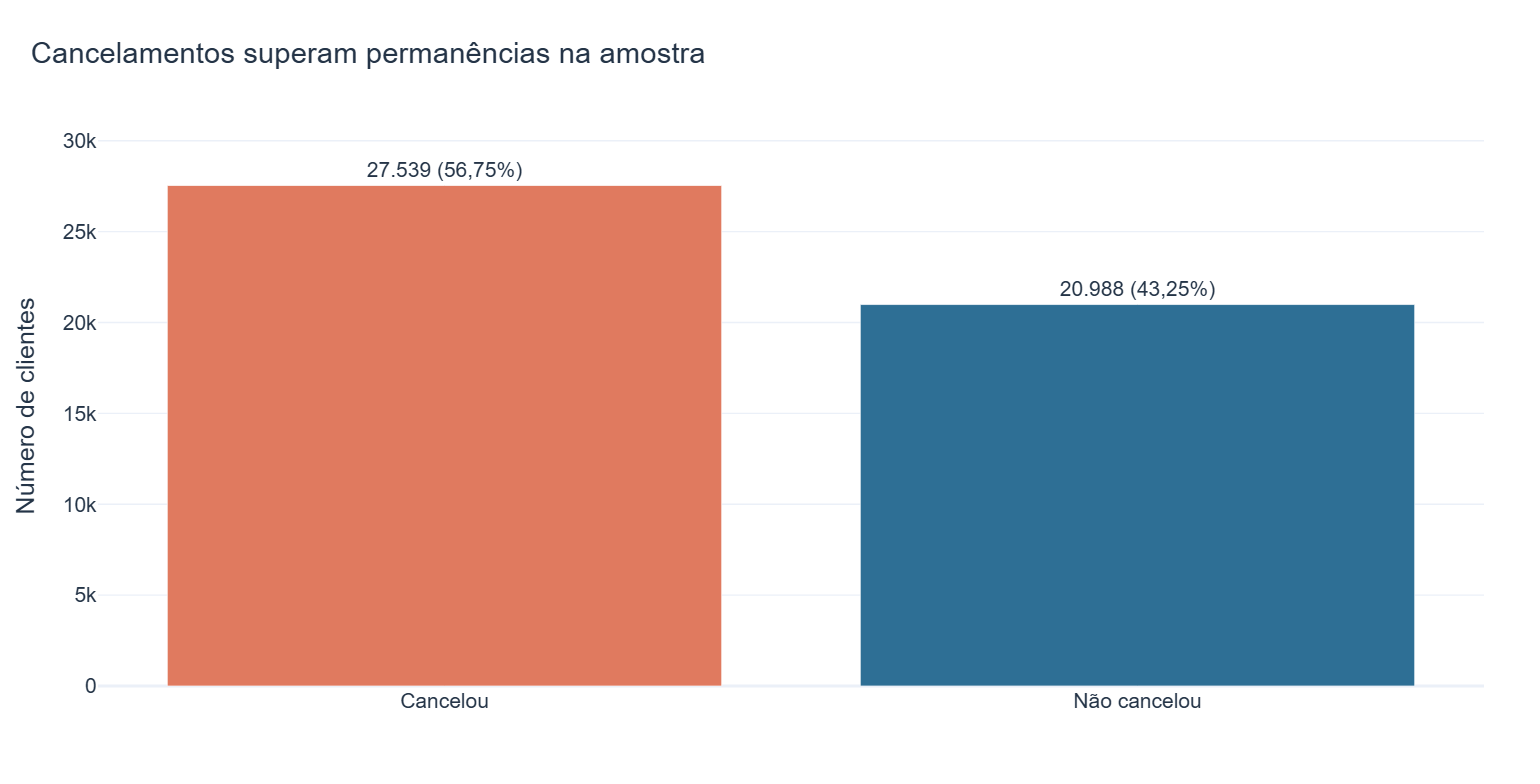

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/imagens/taxa-geral.png')

In [4]:
overall = (
    data["cancelou"]
    .value_counts()
    .rename(index={0: "Não cancelou", 1: "Cancelou"})
    .rename_axis("Situação")
    .reset_index(name="Clientes")
)
overall["Percentual"] = overall["Clientes"] / overall["Clientes"].sum()
overall["Rótulo"] = overall.apply(
    lambda row: f"{row['Clientes']:,}".replace(",", ".") + f" ({percent(row['Percentual'])})",
    axis=1,
)

fig = px.bar(
    overall,
    x="Situação",
    y="Clientes",
    color="Situação",
    text="Rótulo",
    color_discrete_map=PALETTE,
    title="Cancelamentos superam permanências na amostra",
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(title="Número de clientes")
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
finish_chart(fig, "taxa-geral.png")

## 3. Duração do contrato

Contrato é a segmentação mais forte da base. Todos os 9.595 clientes com contrato mensal aparecem como cancelados, enquanto as taxas de contratos anual e trimestral ficam próximas de 46%.

Esse padrão extremamente determinístico também é um alerta de que a base pode ser sintética ou construída para ensino. Ele é útil para demonstrar análise, mas não comprova que alterar o contrato causaria redução do churn.

,Contrato,Clientes,Cancelamentos,Rótulo
1,Mensal,9595,9595,"100,00%"
0,Anual,19544,9064,"46,38%"
2,Trimestral,19388,8880,"45,80%"


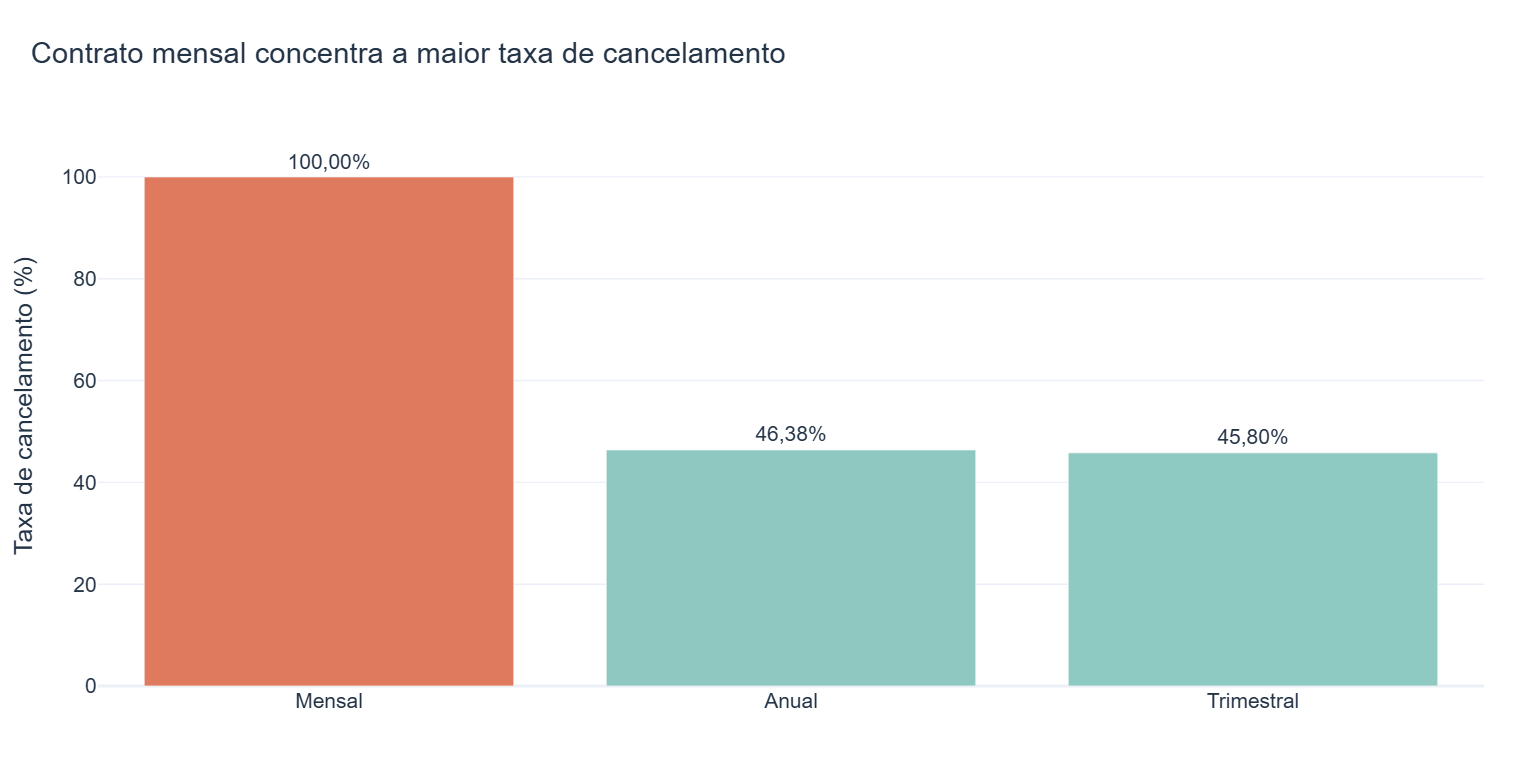

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/imagens/churn-por-contrato.png')

In [5]:
contract = (
    data.groupby("duracao_contrato", observed=False)["cancelou"]
    .agg(Clientes="size", Cancelamentos="sum", Taxa="mean")
    .reset_index()
)
contract["Contrato"] = contract["duracao_contrato"].replace({
    "Monthly": "Mensal",
    "Quarterly": "Trimestral",
    "Annual": "Anual",
})
contract["Taxa (%)"] = contract["Taxa"] * 100
contract["Rótulo"] = contract["Taxa"].map(percent)
contract = contract.sort_values("Taxa (%)", ascending=False)
display(contract[["Contrato", "Clientes", "Cancelamentos", "Rótulo"]])

fig = px.bar(
    contract,
    x="Contrato",
    y="Taxa (%)",
    text="Rótulo",
    color="Taxa (%)",
    color_continuous_scale=["#8EC9C2", "#E07A5F"],
    title="Contrato mensal concentra a maior taxa de cancelamento",
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(title="Taxa de cancelamento (%)", range=[0, 110])
fig.update_xaxes(title="")
fig.update_layout(coloraxis_showscale=False)
finish_chart(fig, "churn-por-contrato.png")

## 4. Contatos com o call center

A taxa cresce conforme aumenta o número de ligações. Entre clientes com cinco ou mais contatos, 99,02% aparecem como cancelados. O dado sugere que repetidos contatos podem funcionar como sinal de problema não resolvido.

**Ação a testar:** criar alerta após o terceiro contato e encaminhar o caso para uma equipe de retenção. O teste deve comparar grupos semelhantes antes de afirmar impacto.

,faixa_ligacoes,Clientes,Cancelamentos,Rótulo
0,0 a 1,15410,4688,"30,42%"
1,2 a 3,13078,4698,"35,92%"
2,4,4275,2543,"59,49%"
3,5 ou mais,15764,15610,"99,02%"


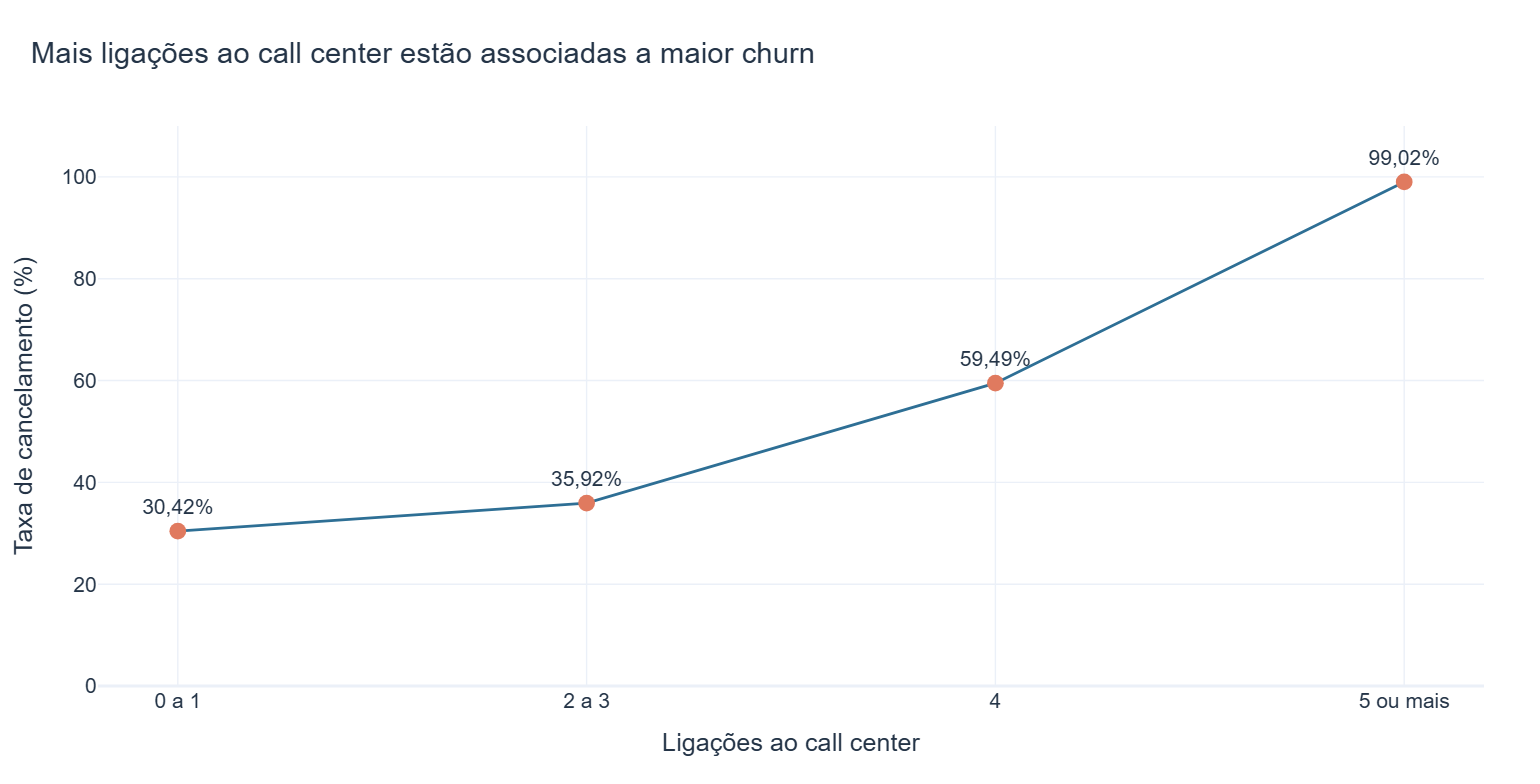

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/imagens/churn-por-callcenter.png')

In [6]:
call_labels = ["0 a 1", "2 a 3", "4", "5 ou mais"]
data["faixa_ligacoes"] = pd.cut(
    data["ligacoes_callcenter"],
    bins=[-1, 1, 3, 4, float("inf")],
    labels=call_labels,
)
calls = (
    data.groupby("faixa_ligacoes", observed=False)["cancelou"]
    .agg(Clientes="size", Cancelamentos="sum", Taxa="mean")
    .reset_index()
)
calls["Taxa (%)"] = calls["Taxa"] * 100
calls["Rótulo"] = calls["Taxa"].map(percent)
display(calls[["faixa_ligacoes", "Clientes", "Cancelamentos", "Rótulo"]])

fig = px.line(
    calls,
    x="faixa_ligacoes",
    y="Taxa (%)",
    text="Rótulo",
    markers=True,
    title="Mais ligações ao call center estão associadas a maior churn",
)
fig.update_traces(line_color="#2E6F95", marker=dict(size=12, color="#E07A5F"), textposition="top center")
fig.update_yaxes(title="Taxa de cancelamento (%)", range=[0, 110])
fig.update_xaxes(title="Ligações ao call center")
finish_chart(fig, "churn-por-callcenter.png")

## 5. Atraso no pagamento

Até 20 dias, a taxa de cancelamento permanece ao redor de 46%. Na faixa de 21 dias ou mais, todos os 9.356 clientes aparecem como cancelados.

**Ação a testar:** iniciar lembretes e negociação antes do vigésimo dia. Novamente, a base mostra associação; não mede o efeito real de uma campanha de cobrança.

,faixa_atraso,Clientes,Cancelamentos,Rótulo
0,0 a 5,11139,5171,"46,42%"
1,6 a 10,9229,4332,"46,94%"
2,11 a 15,9484,4352,"45,89%"
3,16 a 20,9319,4328,"46,44%"
4,21 ou mais,9356,9356,"100,00%"


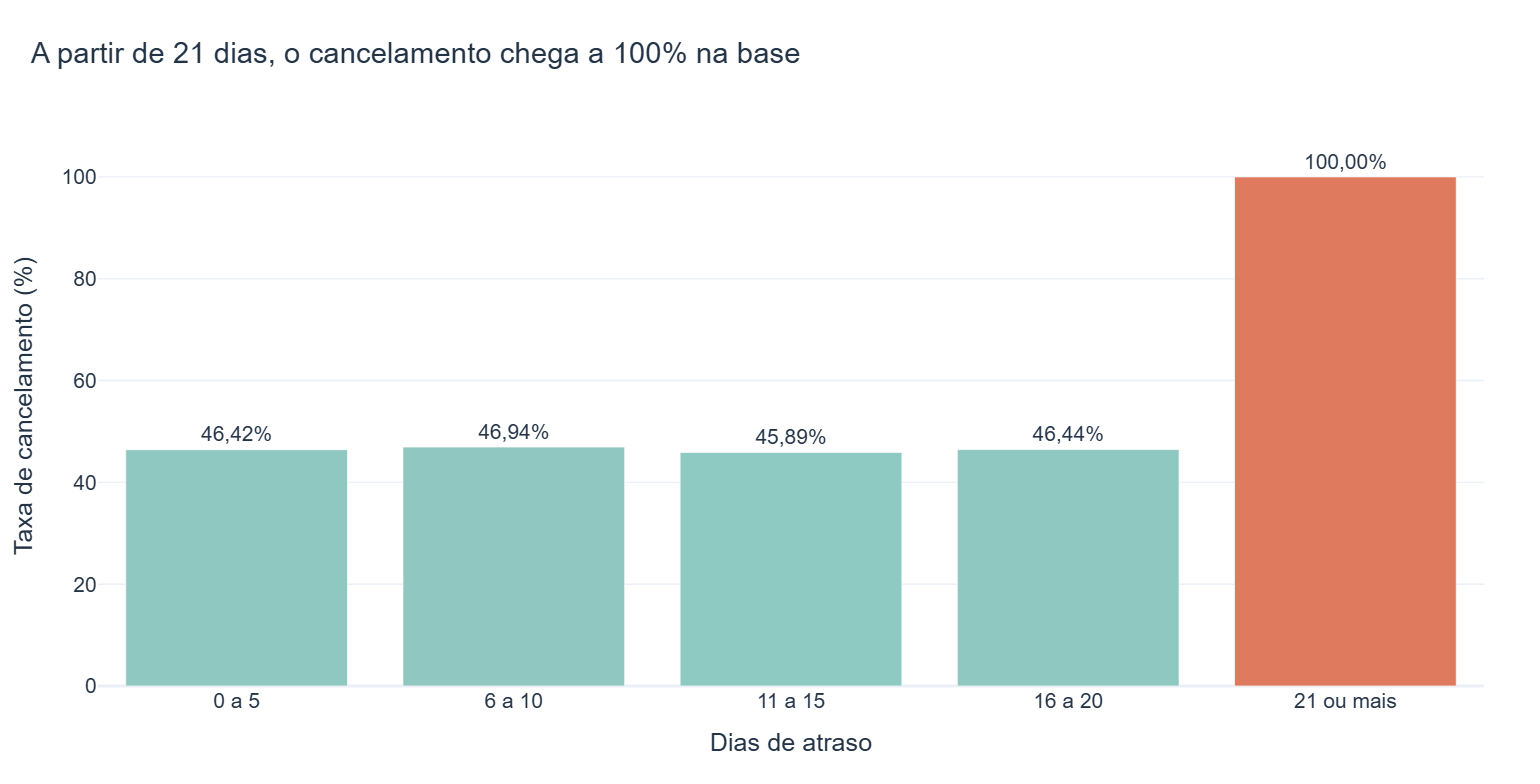

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/imagens/churn-por-atraso.png')

In [7]:
delay_labels = ["0 a 5", "6 a 10", "11 a 15", "16 a 20", "21 ou mais"]
data["faixa_atraso"] = pd.cut(
    data["dias_atraso"],
    bins=[-1, 5, 10, 15, 20, float("inf")],
    labels=delay_labels,
)
delays = (
    data.groupby("faixa_atraso", observed=False)["cancelou"]
    .agg(Clientes="size", Cancelamentos="sum", Taxa="mean")
    .reset_index()
)
delays["Taxa (%)"] = delays["Taxa"] * 100
delays["Rótulo"] = delays["Taxa"].map(percent)
display(delays[["faixa_atraso", "Clientes", "Cancelamentos", "Rótulo"]])

fig = px.bar(
    delays,
    x="faixa_atraso",
    y="Taxa (%)",
    text="Rótulo",
    color="Taxa (%)",
    color_continuous_scale=["#8EC9C2", "#E07A5F"],
    title="A partir de 21 dias, o cancelamento chega a 100% na base",
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(title="Taxa de cancelamento (%)", range=[0, 110])
fig.update_xaxes(title="Dias de atraso")
fig.update_layout(coloraxis_showscale=False)
finish_chart(fig, "churn-por-atraso.png")

## 6. Tempo desde a última interação

Clientes com mais de 12 meses desde a última interação apresentam churn de 62,74%, acima das faixas mais recentes, que ficam próximas de 49% a 50%.

**Ação a testar:** criar uma régua de reengajamento antes de o cliente completar 12 meses sem interação.

,faixa_interacao,Clientes,Cancelamentos,Rótulo
0,1 a 3,5505,2760,"50,14%"
1,4 a 6,5484,2715,"49,51%"
2,7 a 12,10981,5402,"49,19%"
3,13 ou mais,26557,16662,"62,74%"


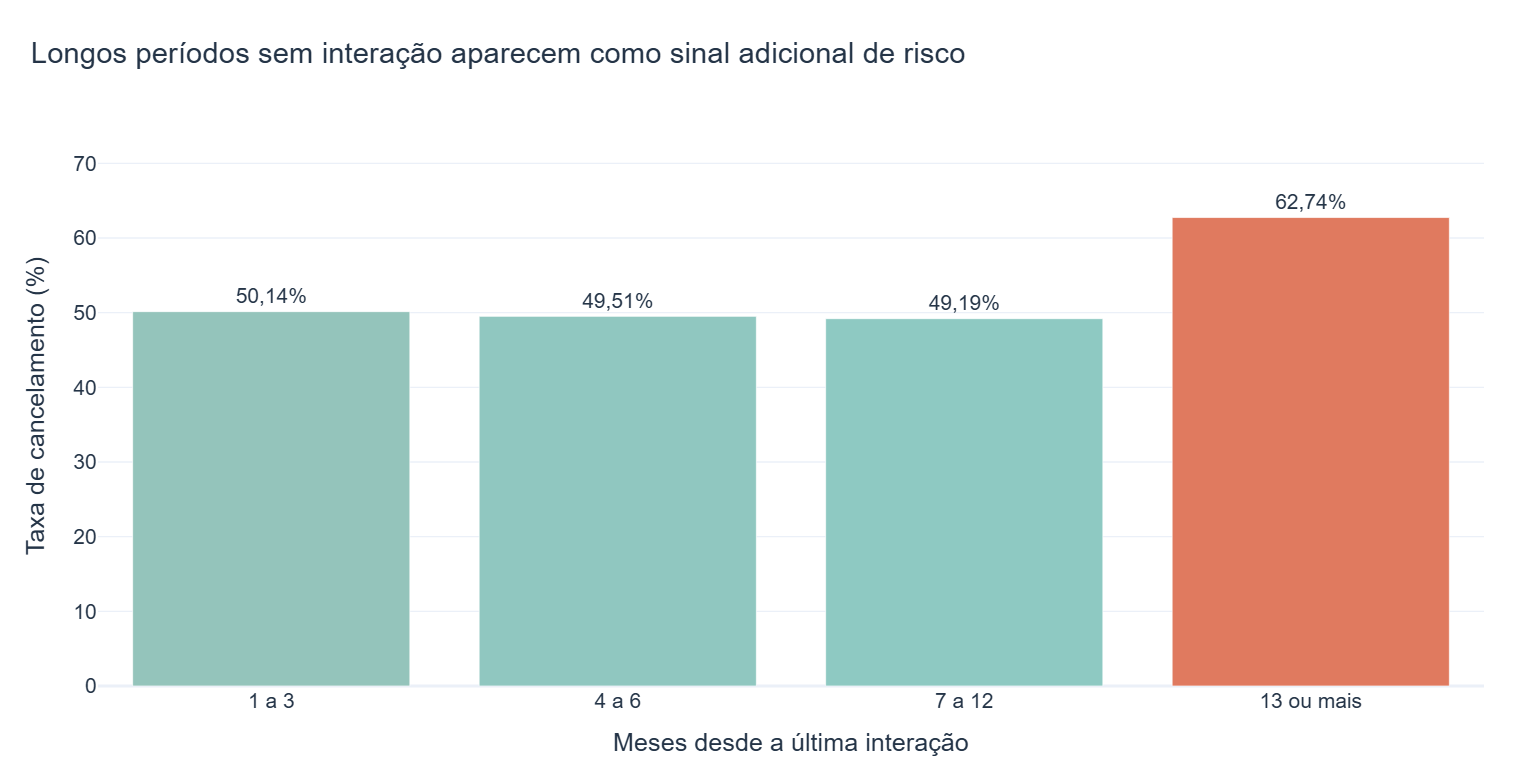

WindowsPath('C:/Users/pd200/Documents/Codex/2026-10-08/ana/work/repo-audit/analise-de-cancelamento/imagens/churn-por-interacao.png')

In [8]:
interaction_labels = ["1 a 3", "4 a 6", "7 a 12", "13 ou mais"]
data["faixa_interacao"] = pd.cut(
    data["meses_ultima_interacao"],
    bins=[0, 3, 6, 12, float("inf")],
    labels=interaction_labels,
)
interactions = (
    data.groupby("faixa_interacao", observed=False)["cancelou"]
    .agg(Clientes="size", Cancelamentos="sum", Taxa="mean")
    .reset_index()
)
interactions["Taxa (%)"] = interactions["Taxa"] * 100
interactions["Rótulo"] = interactions["Taxa"].map(percent)
display(interactions[["faixa_interacao", "Clientes", "Cancelamentos", "Rótulo"]])

fig = px.bar(
    interactions,
    x="faixa_interacao",
    y="Taxa (%)",
    text="Rótulo",
    color="Taxa (%)",
    color_continuous_scale=["#8EC9C2", "#E07A5F"],
    title="Longos períodos sem interação aparecem como sinal adicional de risco",
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(title="Taxa de cancelamento (%)", range=[0, 75])
fig.update_xaxes(title="Meses desde a última interação")
fig.update_layout(coloraxis_showscale=False)
finish_chart(fig, "churn-por-interacao.png")

## 7. Cenário descritivo, não previsão

O material original filtrava clientes sem contrato mensal, com até quatro ligações e até 20 dias de atraso. Esse recorte é mantido apenas para mostrar a diferença entre grupos existentes.

Ele **não** representa uma previsão de que ações comerciais reduziriam o churn para o mesmo valor.

In [9]:
lower_risk_subset = data[
    (data["duracao_contrato"] != "Monthly")
    & (data["ligacoes_callcenter"] <= 4)
    & (data["dias_atraso"] <= 20)
]

scenario = pd.DataFrame({
    "Grupo": ["Amostra completa", "Recorte sem os três sinais principais"],
    "Clientes": [len(data), len(lower_risk_subset)],
    "Taxa de cancelamento": [data["cancelou"].mean(), lower_risk_subset["cancelou"].mean()],
})
scenario["Taxa formatada"] = scenario["Taxa de cancelamento"].map(percent)
scenario["Participação na amostra"] = (scenario["Clientes"] / len(data)).map(percent)
display(scenario[["Grupo", "Clientes", "Taxa formatada", "Participação na amostra"]])

,Grupo,Clientes,Taxa formatada,Participação na amostra
0,Amostra completa,48527,"56,75%","100,00%"
1,Recorte sem os três sinais principais,25539,"18,42%","52,63%"


## 8. Conclusão executiva

### Principais achados

1. A taxa geral de churn na amostra limpa é **56,75%**.
2. Contrato mensal é o sinal mais forte: os **9.595 clientes** dessa categoria aparecem como cancelados.
3. Clientes com **cinco ou mais ligações** apresentam churn de **99,02%**.
4. Clientes com **21 dias ou mais de atraso** apresentam churn de **100%**.
5. Mais de 12 meses sem interação está associado a churn de **62,74%**, acima das faixas mais recentes.

### Ações que merecem teste

- Testar incentivos de migração do contrato mensal para planos mais longos.
- Criar alerta após o terceiro contato com o call center e tratar reincidências.
- Antecipar cobrança e negociação antes do vigésimo dia de atraso.
- Acionar campanhas de reengajamento antes de 12 meses sem interação.

### Limitações

- A origem empresarial, o período de coleta e a licença dos dados não estão documentados.
- Padrões de 100% sugerem uma base sintética ou construída para ensino.
- A análise é descritiva e não controla confundidores.
- O recorte de menor risco apresenta churn de **18,42%**, mas isso não mede o efeito de nenhuma intervenção.

### Próximos passos em um projeto real

Validar a procedência dos dados, incluir período de observação, definir churn com precisão, acompanhar coortes no tempo e executar testes controlados antes de atribuir causalidade às ações.